# 01 · Exploración de datos — Argly
Dataset sintético (semilla fija) de siniestros con patrones de posible fraude **plantados y etiquetados**. 100% sintético, sin PII.

In [1]:
import sys, pathlib
p = pathlib.Path.cwd()
while not (p / 'src').exists() and p != p.parent:
    p = p.parent
sys.path.insert(0, str(p))

In [2]:
from src.ingestion.generate_synthetic import generar
dfs = generar(seed=42)
{k: len(v) for k, v in dfs.items()}

{'asegurados': 600,
 'proveedores': 80,
 'polizas': 891,
 'vehiculos': 466,
 'siniestros': 1465,
 'documentos': 4395}

## Tablas del reto y sus columnas

In [3]:
for k, v in dfs.items():
    print(f'\n=== {k} ({len(v)} filas) ===')
    print(list(v.columns))


=== asegurados (600 filas) ===
['id_asegurado', 'segmento', 'ciudad', 'antiguedad_meses', 'score_cliente', 'telefono', 'en_lista_restrictiva', 'numero_polizas', 'reclamos_ultimos_12_meses', 'mora_actual']

=== proveedores (80 filas) ===
['id_proveedor', 'tipo', 'ciudad', 'antiguedad_meses', 'en_lista_restrictiva', 'reclamos_asociados', 'monto_promedio_reclamado', 'porcentaje_casos_observados']

=== polizas (891 filas) ===
['id_poliza', 'id_asegurado', 'ramo', 'fecha_inicio', 'fecha_fin', 'prima', 'suma_asegurada', 'deducible', 'canal_venta', 'ciudad', 'estado_poliza']

=== vehiculos (466 filas) ===
['placa', 'chasis', 'motor', 'marca', 'modelo', 'anio', 'id_asegurado', 'id_poliza']

=== siniestros (1465 filas) ===
['id_siniestro', 'id_poliza', 'id_asegurado', 'id_proveedor', 'placa', 'id_conductor', 'perdida_total', 'ramo', 'cobertura', 'fecha_ocurrencia', 'fecha_reporte', 'monto_reclamado', 'monto_estimado', 'monto_pagado', 'estado', 'sucursal', 'descripcion', 'documentos_completos',

## Distribución de patrones plantados (ground-truth)

In [4]:
s = dfs['siniestros']
print('Fraude simulado:', int(s['etiqueta_fraude_simulada'].sum()), 'de', len(s))
s[s['etiqueta_fraude_simulada'] == 1]['patron'].value_counts()

Fraude simulado: 365 de 1465


patron
borde_vigencia          60
demora_robo             50
frecuencia_asegurado    43
doc_inconsistente       30
monto_alto              25
sin_tercero             25
ptxrb                   25
red_proveedor           24
narrativa_clonada       20
geo_imposible           20
clima_inconsistente     20
frecuencia_rc           15
frecuencia_conductor     8
Name: count, dtype: int64

## Train / test separados (rings con proveedores distintos)

In [5]:
s['split'].value_counts()

split
train    1021
test      444
Name: count, dtype: int64

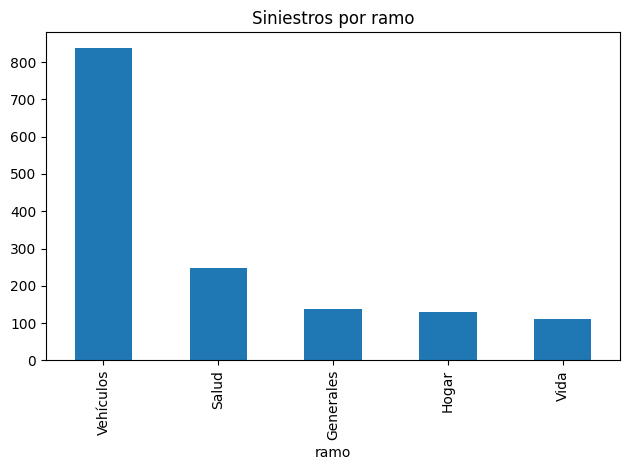

In [6]:
import matplotlib.pyplot as plt
s['ramo'].value_counts().plot(kind='bar', title='Siniestros por ramo')
plt.tight_layout(); plt.show()